In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import re
import warnings
warnings.filterwarnings("ignore")

In [3]:
df=pd.read_csv("laptop.csv")
df

,Product_Name,Price,Ratings,Features,Page_Num,Original_Price,Discount,Review
0,Samsung Galaxy Book4 Metal Intel Core i5 13th ...,"₹52,730",4.4,Intel Core i5 Processor (13th Gen)8 GB LPDDR4X...,1,"₹78,189",32% off,"16,070 Ratings & 1,280 Reviews"
1,Lenovo LOQ Essential Intel Core i7 12650HX - (...,"₹79,990",4.4,Intel Core i7 Processor16 GB DDR5 RAMWindows 1...,1,"₹1,00,990",20% off,70 Ratings & 4 Reviews
2,ASUS Expertbook P1 Intel Core i3 13th Gen 1315...,"₹39,990",4.3,Intel Core i3 Processor (13th Gen)16 GB DDR5 R...,1,"₹74,990",46% off,"4,679 Ratings & 397 Reviews"
3,Acer Aspire 3 Intel Celeron Dual Core - (8 GB/...,"₹28,990",3.8,Intel Celeron Dual Core Processor8 GB DDR4 RAM...,1,"₹35,999",19% off,"8,299 Ratings & 720 Reviews"
4,HP Intel Core i7 13th Gen 13620H - (16 GB/512 ...,"₹69,990",4.3,Intel Core i7 Processor (13th Gen)16 GB DDR4 R...,1,"₹77,507",9% off,822 Ratings & 53 Reviews
...,...,...,...,...,...,...,...,...
955,DELL Inspiron 15 Intel Core i5 13th Gen 1334U ...,"₹53,990",4.2,Intel Core i5 Processor (13th Gen)8 GB DDR4 RA...,41,"₹59,990",10% off,439 Ratings & 20 Reviews
956,ASUS ROG Strix G16 (2025) with Office 2024 + M...,"₹2,38,990",4.7,AMD Ryzen 9 16 Core Processor16 GB DDR5 RAMWin...,41,"₹2,39,990",NaN,28 Ratings & 2 Reviews
957,MSI Thin A15 B7UC AMD Ryzen 5 Hexa Core 7535HS...,"₹71,190",4.4,AMD Ryzen 5 Hexa Core Processor16 GB DDR5 RAM6...,41,"₹82,990",14% off,292 Ratings & 26 Reviews
958,HP 15s Intel Core i7 13th Gen 1360P - (16 GB/5...,"₹88,990",4.3,Intel Core i7 Processor (13th Gen)16 GB DDR4 R...,41,"₹98,990",10% off,378 Ratings & 27 Reviews


In [6]:
df.shape

(960, 8)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Product_Name    960 non-null    object 
 1   Price           959 non-null    object 
 2   Ratings         867 non-null    float64
 3   Features        960 non-null    object 
 4   Page_Num        960 non-null    int64  
 5   Original_Price  920 non-null    object 
 6   Discount        910 non-null    object 
 7   Review          867 non-null    object 
dtypes: float64(1), int64(1), object(6)
memory usage: 60.1+ KB


In [8]:
df.isnull().sum()

Product_Name       0
Price              1
Ratings           93
Features           0
Page_Num           0
Original_Price    40
Discount          50
Review            93
dtype: int64

In [9]:
df["Price"].fillna(df["Price"].mode()[0],inplace = True)

In [11]:
df["Ratings"].mode()[0]

4.4

In [12]:
df["Ratings"].fillna(df["Ratings"].mode()[0],inplace = True)

In [13]:
df["Original_Price"].fillna(df["Original_Price"].mode()[0],inplace = True)

In [15]:
df["Discount"].fillna(df["Discount"].mode()[0],inplace = True)

In [16]:
df["Review"].fillna(df["Review"].mode()[0],inplace = True)

In [17]:
df.isnull().sum()

Product_Name      0
Price             0
Ratings           0
Features          0
Page_Num          0
Original_Price    0
Discount          0
Review            0
dtype: int64

In [18]:
df.duplicated().sum()

0

In [23]:
df["Brand"] = df["Product_Name"].apply(lambda x:re.findall(r"^\w+",x)[0])

<Axes: xlabel='Brand'>

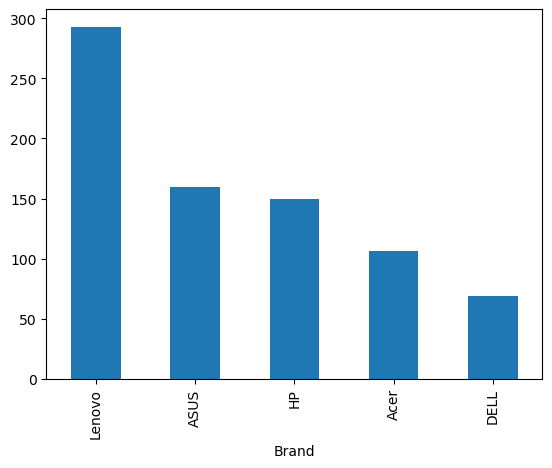

In [25]:
# df["Brand"].value_counts().head().plot(kind="bar")

In [29]:
df["processor"] = df["Features"].apply(lambda x:re.findall(r"^\w+",x)[0])

<Axes: xlabel='processor'>

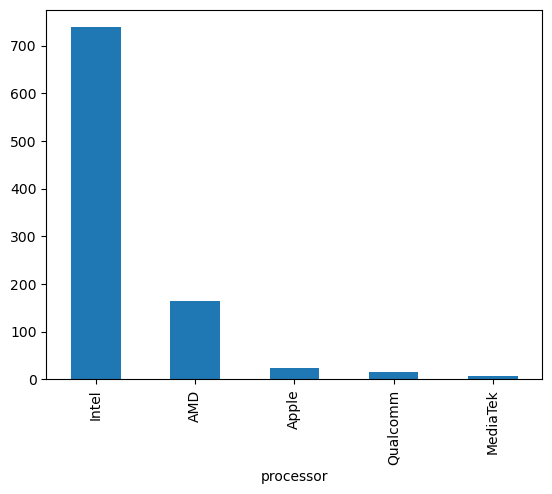

In [31]:
df["processor"].value_counts().head().plot(kind="bar")

In [32]:
df.head(1)

,Product_Name,Price,Ratings,Features,Page_Num,Original_Price,Discount,Review,Brand,processor
0,Samsung Galaxy Book4 Metal Intel Core i5 13th ...,"₹52,730",4.4,Intel Core i5 Processor (13th Gen)8 GB LPDDR4X...,1,"₹78,189",32% off,"16,070 Ratings & 1,280 Reviews",Samsung,Intel


In [36]:
 df["Rating1"] = df["Review"].apply(lambda x: re.split(r"[&]",x)[0])

In [42]:
df["no_of_ratings"] = df["Rating1"].apply(lambda x: re.findall(r"[\d,]+",x)[0].replace(",","")).astype("int")

In [45]:
df["Reviews1"] =  df["Review"].apply(lambda x: re.split(r"[&]",x)[1])

In [47]:
df["no_of_Reviews"] = df["Reviews1"].apply(lambda x: re.findall(r"[\d,]+",x)[0].replace(",","")).astype("int")

In [48]:
df.shape

(960, 14)

In [53]:
df["Price"] = df["Price"].apply(lambda x: re.sub(r"[₹,]","",x)).astype("int")

In [54]:
df["Original_Price"] = df["Original_Price"].apply(lambda x: re.sub(r"[₹,]","",x)).astype("int")

In [55]:
df.head(1)

,Product_Name,Price,Ratings,Features,Page_Num,Original_Price,Discount,Review,Brand,processor,Rating1,no_of_ratings,Reviews1,no_of_Reviews
0,Samsung Galaxy Book4 Metal Intel Core i5 13th ...,52730,4.4,Intel Core i5 Processor (13th Gen)8 GB LPDDR4X...,1,78189,32% off,"16,070 Ratings & 1,280 Reviews",Samsung,Intel,"16,070 Ratings",16070,"1,280 Reviews",1280


In [60]:
df["Discount"] = df["Discount"].apply(lambda x: re.findall(r"[\d%]+",x)[0])

In [61]:
df["Features"][0]

'Intel Core i5 Processor (13th Gen)8 GB LPDDR4X RAMWindows 11 Operating System512 GB SSD39.62 cm (15.6 Inch) Display1 Year Manufacturer Warranty for Laptop and 6 Months for In-Box Accessories'

In [64]:
df["GB_List"] = df["Features"].apply(lambda x: re.findall(r"(\d+)\s*GB",x))

In [68]:
df["RAM"] = df["GB_List"].apply(lambda x:x[0] if len(x)>0 else np.nan).astype("int")

In [71]:
df["RAM"].value_counts()

RAM
16    572
8     299
32     30
24     23
4      22
12     10
36      2
48      1
18      1
Name: count, dtype: int64

In [75]:
df["Storage"] = df["GB_List"].apply(lambda x:x[1] if len(x)>1 else np.nan)

In [76]:
df["Storage"].isnull().sum()

193

In [77]:
df["Storage"].value_counts()

Storage
512    713
256     50
128      4
Name: count, dtype: int64

In [78]:
df["Storage"].fillna(df["Storage"].mode()[0],inplace = True)

In [79]:
df["Storage"] = df["Storage"].astype("int")

In [81]:
df.columns

Index(['Product_Name', 'Price', 'Ratings', 'Features', 'Page_Num',
       'Original_Price', 'Discount', 'Review', 'Brand', 'processor', 'Rating1',
       'no_of_ratings', 'Reviews1', 'no_of_Reviews', 'GB_List', 'RAM',
       'Storage'],
      dtype='object')

In [82]:
df.drop(columns = ['Product_Name','Features','Rating1','Reviews1','Review','GB_List'],inplace = True)

In [83]:
df.columns

Index(['Price', 'Ratings', 'Page_Num', 'Original_Price', 'Discount', 'Brand',
       'processor', 'no_of_ratings', 'no_of_Reviews', 'RAM', 'Storage'],
      dtype='object')

In [84]:
df.shape

(960, 11)

In [85]:
df

,Price,Ratings,Page_Num,Original_Price,Discount,Brand,processor,no_of_ratings,no_of_Reviews,RAM,Storage
0,52730,4.4,1,78189,32%,Samsung,Intel,16070,1280,8,512
1,79990,4.4,1,100990,20%,Lenovo,Intel,70,4,16,512
2,39990,4.3,1,74990,46%,ASUS,Intel,4679,397,16,512
3,28990,3.8,1,35999,19%,Acer,Intel,8299,720,8,512
4,69990,4.3,1,77507,9%,HP,Intel,822,53,16,512
...,...,...,...,...,...,...,...,...,...,...,...
955,53990,4.2,41,59990,10%,DELL,Intel,439,20,8,512
956,238990,4.7,41,239990,19%,ASUS,AMD,28,2,16,512
957,71190,4.4,41,82990,14%,MSI,AMD,292,26,16,512
958,88990,4.3,41,98990,10%,HP,Intel,378,27,16,512


In [86]:
df.isnull().sum()

Price             0
Ratings           0
Page_Num          0
Original_Price    0
Discount          0
Brand             0
processor         0
no_of_ratings     0
no_of_Reviews     0
RAM               0
Storage           0
dtype: int64

In [87]:
df.duplicated().sum()

0

<Axes: xlabel='Price', ylabel='Count'>

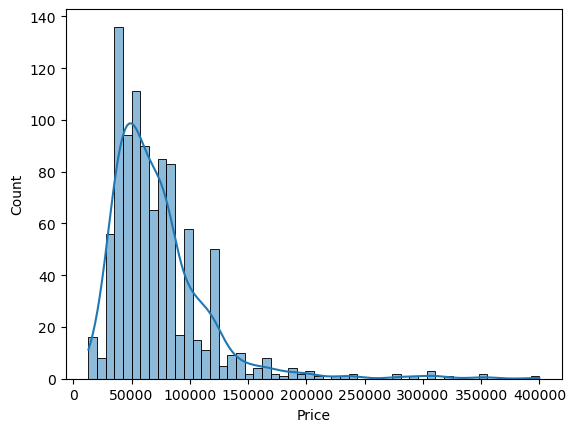

In [89]:
sns.histplot(x= "Price",data = df,kde = True)

In [90]:
q1 = df["Price"].quantile(0.25)
q3 = df["Price"].quantile(0.75)
iqr = q3-q1
outliers = df[(df["Price"]<q1-1.5*iqr) | (df["Price"] >q3+1.5*iqr)]

<Axes: xlabel='Brand'>

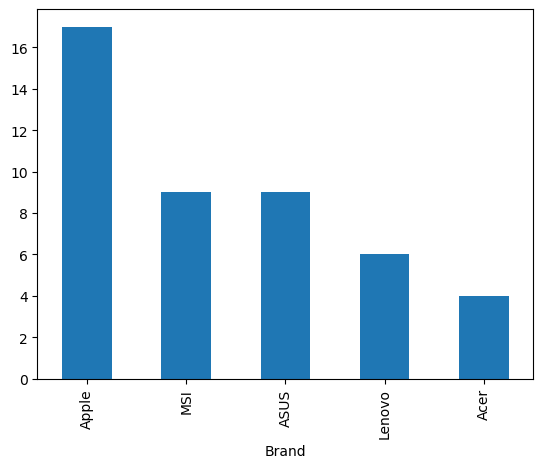

In [95]:
outliers["Brand"].value_counts().head().plot(kind ="bar")

<Axes: xlabel='RAM', ylabel='Price'>

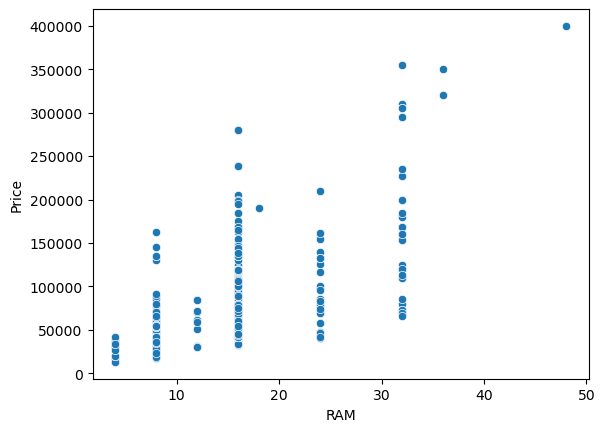

In [96]:
sns.scatterplot(x= "RAM",y = "Price",data = df)

<Axes: xlabel='Price', ylabel='RAM'>

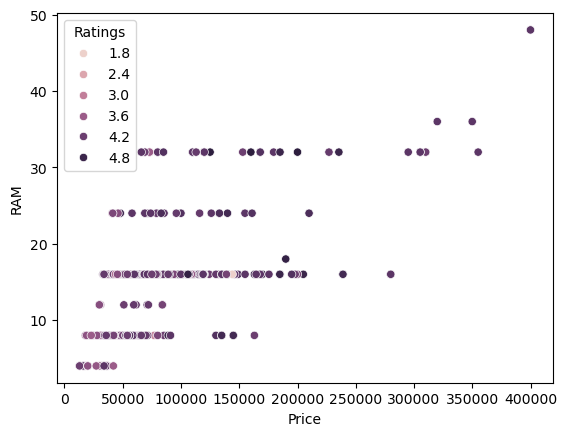

In [97]:
sns.scatterplot(x = "Price",y = "RAM",hue = "Ratings",data = df)

<Axes: >

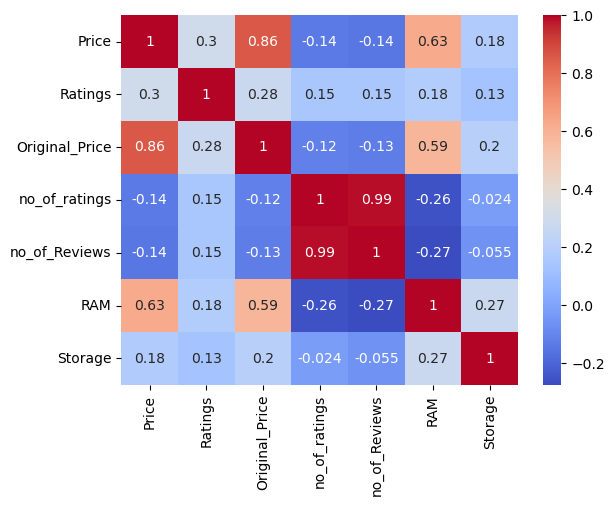

In [98]:
sns.heatmap(df.select_dtypes(include = ["int32","float64"]).corr(),annot = True,cmap = "coolwarm")